In [8]:
!pip install Pillow tqdm --quiet

import os
import random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw, ImageFilter
from tqdm import tqdm


[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [9]:
# Representasi Braille: 6 titik (2 kolom x 3 baris)
# Format array: [1, 2, 3, 4, 5, 6] -> 1 artinya titik timbul, 0 artinya rata.
braille_map = {
    'a': [1, 0, 0, 0, 0, 0],
    'b': [1, 1, 0, 0, 0, 0],
    'c': [1, 0, 0, 1, 0, 0],
    'd': [1, 0, 0, 1, 1, 0],
    'e': [1, 0, 0, 0, 1, 0],
    'f': [1, 1, 0, 1, 0, 0],
    'g': [1, 1, 0, 1, 1, 0],
    'h': [1, 1, 0, 0, 1, 0],
    'i': [0, 1, 0, 1, 0, 0],
    'j': [0, 1, 0, 1, 1, 0],
    'k': [1, 0, 1, 0, 0, 0],
    'l': [1, 1, 1, 0, 0, 0],
    'm': [1, 0, 1, 1, 0, 0],
    'n': [1, 0, 1, 1, 1, 0],
    'o': [1, 0, 1, 0, 1, 0],
    'p': [1, 1, 1, 1, 0, 0],
    'q': [1, 1, 1, 1, 1, 0],
    'r': [1, 1, 1, 0, 1, 0],
    's': [0, 1, 1, 1, 0, 0],
    't': [0, 1, 1, 1, 1, 0],
    'u': [1, 0, 1, 0, 0, 1],
    'v': [1, 1, 1, 0, 0, 1],
    'w': [0, 1, 0, 1, 1, 1],
    'x': [1, 0, 1, 1, 0, 1],
    'y': [1, 0, 1, 1, 1, 1],
    'z': [1, 0, 1, 0, 1, 1]
}

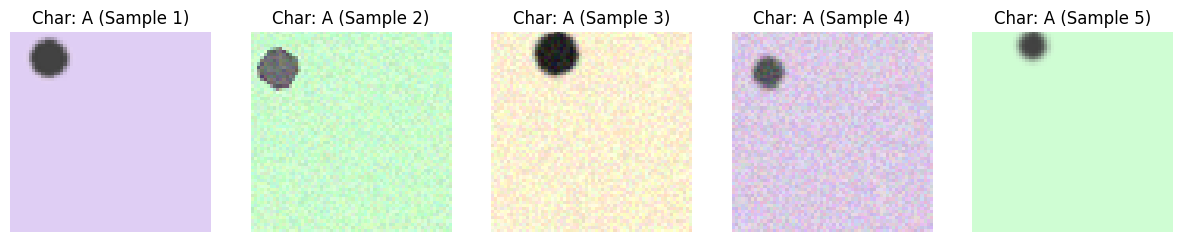

In [10]:
def generate_braille_image(char, img_size=(64, 64)):
    """
    Generate citra Braille dengan variasi/augmentasi acak.
    """
    # Background color: variasi dari kertas putih hingga agak abu-abu/kuning
    bg_color = (
        random.randint(200, 255),
        random.randint(200, 255),
        random.randint(200, 255)
    )
    img = Image.new('RGB', img_size, color=bg_color)
    draw = ImageDraw.Draw(img)
    
    dots = braille_map[char.lower()]
    
    # Margin dan Spacing
    margin_x = img_size[0] * 0.25
    margin_y = img_size[1] * 0.15
    spacing_x = (img_size[0] - 2 * margin_x) 
    spacing_y = (img_size[1] - 2 * margin_y) / 2
    
    # Radius titik dan variasi offset
    base_radius = random.uniform(4.0, 6.5)
    
    # Kumpulan koordinat grid (2 kolom, 3 baris)
    # Kolom 1: dot 1, 2, 3
    # Kolom 2: dot 4, 5, 6
    grid = [
        (margin_x, margin_y),
        (margin_x, margin_y + spacing_y),
        (margin_x, margin_y + 2 * spacing_y),
        (margin_x + spacing_x, margin_y),
        (margin_x + spacing_x, margin_y + spacing_y),
        (margin_x + spacing_x, margin_y + 2 * spacing_y),
    ]
    
    # Global offset untuk mensimulasikan crop yang tidak persis di tengah
    global_offset_x = random.uniform(-4, 4)
    global_offset_y = random.uniform(-4, 4)
    
    for idx, is_active in enumerate(dots):
        if is_active:
            # Warna titik (biasanya lebih gelap karena efek bayangan / emboss)
            dot_shade = random.randint(30, 120)
            dot_color = (dot_shade, dot_shade, dot_shade)
            
            # Local offset untuk setiap titik
            offset_x = random.uniform(-1.5, 1.5)
            offset_y = random.uniform(-1.5, 1.5)
            
            cx = grid[idx][0] + global_offset_x + offset_x
            cy = grid[idx][1] + global_offset_y + offset_y
            r = base_radius * random.uniform(0.9, 1.1)
            
            draw.ellipse([cx - r, cy - r, cx + r, cy + r], fill=dot_color)
            
    # --- AUGMENTATION (Variansi Data) ---
    
    # 1. Rotasi (Rotation) -15 hingga 15 derajat
    angle = random.uniform(-15, 15)
    img = img.rotate(angle, resample=Image.BICUBIC, fillcolor=bg_color)
    
    # 2. Blur (Gaussian Blur)
    if random.random() < 0.7:  # 70% chance to be slightly blurred
        blur_radius = random.uniform(0.3, 1.2)
        img = img.filter(ImageFilter.GaussianBlur(radius=blur_radius))
        
    # 3. Add Gaussian/Uniform Noise
    if random.random() < 0.5: # 50% chance to add noise
        img_np = np.array(img, dtype=np.int16)
        noise = np.random.randint(-20, 20, img_np.shape)
        img_np = np.clip(img_np + noise, 0, 255).astype(np.uint8)
        img = Image.fromarray(img_np)
        
    return img

# Test Preview
fig, axes = plt.subplots(1, 5, figsize=(15, 3))
test_char = 'a'
for i in range(5):
    img = generate_braille_image(test_char)
    axes[i].imshow(img)
    axes[i].axis('off')
    axes[i].set_title(f"Char: {test_char.upper()} (Sample {i+1})")
plt.show()

In [11]:
DATASET_PATH = r"d:\BrailleVision\ml_pipeline\dataset_synthetic"
SAMPLES_PER_CLASS = 1000

print(f"Generating dataset ke: {DATASET_PATH}")

os.makedirs(DATASET_PATH, exist_ok=True)

for char in tqdm(braille_map.keys(), desc="Karakter (A-Z)"):
    # Buat direktori kelas
    class_dir = os.path.join(DATASET_PATH, char)
    os.makedirs(class_dir, exist_ok=True)
        
    # Generate images
    for i in range(SAMPLES_PER_CLASS):
        img = generate_braille_image(char)
        filename = f"{char}_{i:04d}.jpg"
        filepath = os.path.join(class_dir, filename)
        img.save(filepath, format="JPEG", quality=random.randint(85, 95))

print("Proses Sintesis Dataset Selesai!")

Generating dataset ke: d:\BrailleVision\ml_pipeline\dataset_synthetic


Karakter (A-Z): 100%|██████████| 26/26 [00:43<00:00,  1.69s/it]

Proses Sintesis Dataset Selesai!


### Langkah Selanjutnya

Setelah sel selesai dijalankan, Anda akan memiliki sebuah direktori `dataset_synthetic` dengan 26 subdirektori huruf. 
Anda dapat kembali ke notebook `model_training.ipynb`, dan mengganti jalur pembacaan dataset yang awalnya mendownload dari Kaggle, menjadi membaca folder `dataset_synthetic` ini.\n